In [1]:
import pandas as pd, numpy as np, gc, sklearn
from pathlib import Path
from sklearn.model_selection import train_test_split
print("sklearn:", sklearn.__version__)   # define qué TargetEncoder usamos

PROC = Path('../data/processed')
master = pd.read_parquet(PROC / 'master_train.parquet')

y   = master['TARGET'].astype('int8')
ids = master['SK_ID_CURR'].copy()                 # se guarda aparte (no es feature)
X   = master.drop(columns=['TARGET', 'SK_ID_CURR'])

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print(f"X_tr: {X_tr.shape} | X_val: {X_val.shape}")
print(f"positivos -> train: {y_tr.mean()*100:.3f}% | val: {y_val.mean()*100:.3f}% (global 8.07%)")
del master, X; gc.collect()

# --- Inventario de categóricas (SOLO sobre X_tr, sin leakage) ---
cat_cols = X_tr.select_dtypes(include='object').columns.tolist()
print(f"\n{len(cat_cols)} columnas categóricas:")
rows = []
for c in cat_cols:
    vc = X_tr[c].value_counts(dropna=True)
    rows.append({'col': c,
                 'n_cat': int(X_tr[c].nunique(dropna=True)),
                 'null_%': round(X_tr[c].isna().mean()*100, 1),
                 'top_cat': vc.index[0] if len(vc) else None,
                 'top_%': round(vc.iloc[0]/len(X_tr)*100, 1) if len(vc) else None})
print(pd.DataFrame(rows).sort_values('n_cat', ascending=False).to_string(index=False))

# --- Numéricas por % de nulos (para plan de imputación) ---
num = X_tr.select_dtypes(exclude='object')
num_null = (num.isna().mean()*100)
num_null = num_null[num_null > 0].sort_values(ascending=False)
print(f"\nNuméricas con nulos: {len(num_null)} de {num.shape[1]}")
print(num_null.head(30).round(1).to_string())
del num; gc.collect()

sklearn: 1.6.1
X_tr: (246008, 251) | X_val: (61503, 251)
positivos -> train: 8.073% | val: 8.073% (global 8.07%)

16 columnas categóricas:
                       col  n_cat  null_%                       top_cat  top_%
         ORGANIZATION_TYPE     57    17.9        Business Entity Type 3   22.1
           OCCUPATION_TYPE     18    31.3                      Laborers   18.0
          NAME_INCOME_TYPE      8     0.0                       Working   51.6
           NAME_TYPE_SUITE      7     0.4                 Unaccompanied   80.8
        WALLSMATERIAL_MODE      7    50.8                         Panel   21.5
WEEKDAY_APPR_PROCESS_START      7     0.0                       TUESDAY   17.5
        NAME_FAMILY_STATUS      6     0.0                       Married   63.9
         NAME_HOUSING_TYPE      6     0.0             House / apartment   88.8
       NAME_EDUCATION_TYPE      5     0.0 Secondary / secondary special   71.0
        FONDKAPREMONT_MODE      4    68.4              reg oper account

0

In [2]:
import time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

cat_high = ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE']
cat_low  = [c for c in cat_cols if c not in cat_high]
num_cols = [c for c in X_tr.columns
            if c not in cat_cols and c != 'REGION_RATING_CLIENT_W_CITY']
print(f"num={len(num_cols)} | cat_low={len(cat_low)} | cat_high={len(cat_high)}")

prep = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols),
    ('cat_low', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='Missing')),
                          ('oh',  OneHotEncoder(drop='if_binary',
                                                handle_unknown='ignore',
                                                sparse_output=False))]), cat_low),
    ('cat_high', Pipeline([('te', TargetEncoder(target_type='binary', random_state=42)),
                           ('sc', StandardScaler())]), cat_high),
], remainder='drop')

logit = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                           solver='lbfgs', max_iter=1000, n_jobs=-1)
pipe = Pipeline([('prep', prep), ('clf', logit)])

t0 = time.time()
pipe.fit(X_tr, y_tr)
print(f"fit en {time.time()-t0:.1f}s | features tras preprocesamiento: "
      f"{pipe.named_steps['clf'].coef_.shape[1]}")

# Probabilidades para AUC (métrica principal, independiente del umbral)
p_tr  = pipe.predict_proba(X_tr)[:, 1]
p_val = pipe.predict_proba(X_val)[:, 1]
auc_tr, auc_val = roc_auc_score(y_tr, p_tr), roc_auc_score(y_val, p_val)
print(f"\nAUC train: {auc_tr:.4f} | AUC val: {auc_val:.4f} | gap: {auc_tr-auc_val:+.4f}")

# Métricas secundarias en umbral 0.5 (referencia; el tuning de umbral va después)
pred_val = (p_val >= 0.5).astype(int)
print("\nConfusion matrix (val, thr=0.5):\n", confusion_matrix(y_val, pred_val))
print("\n", classification_report(y_val, pred_val, digits=3))

num=234 | cat_low=14 | cat_high=2
fit en 38.9s | features tras preprocesamiento: 302

AUC train: 0.7763 | AUC val: 0.7749 | gap: +0.0014

Confusion matrix (val, thr=0.5):
 [[40161 16377]
 [ 1489  3476]]

               precision    recall  f1-score   support

           0      0.964     0.710     0.818     56538
           1      0.175     0.700     0.280      4965

    accuracy                          0.710     61503
   macro avg      0.570     0.705     0.549     61503
weighted avg      0.901     0.710     0.775     61503



In [3]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_text

# --- Preprocesamiento para ÁRBOLES (ordinal + numéricas crudas con NaN nativo) ---
num_cols_tree = [c for c in X_tr.columns if c not in cat_cols]   # incluye REGION_RATING_CLIENT_W_CITY
prep_tree = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1,
                           encoded_missing_value=-2), cat_cols),
    ('num', 'passthrough', num_cols_tree),
], remainder='drop')
feat_names_tree = cat_cols + num_cols_tree    # mismo orden que produce el ColumnTransformer

def auc_pair(model):
    return (roc_auc_score(y_tr,  model.predict_proba(X_tr)[:, 1]),
            roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))

# (a) Árbol poco profundo -> interpretable
dt_shallow = Pipeline([('prep', prep_tree),
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_leaf=500,
                                   class_weight='balanced', random_state=42))]).fit(X_tr, y_tr)
a_tr, a_val = auc_pair(dt_shallow)
print(f"Árbol shallow (depth=5): AUC train {a_tr:.4f} | val {a_val:.4f} | gap {a_tr-a_val:+.4f}")

# (b) Árbol sin restringir -> overfitting (varianza)
dt_full = Pipeline([('prep', prep_tree),
    ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=42))]).fit(X_tr, y_tr)
f_tr, f_val = auc_pair(dt_full)
print(f"Árbol full (sin podar) : AUC train {f_tr:.4f} | val {f_val:.4f} | gap {f_tr-f_val:+.4f}")
print(f"  -> profundidad={dt_full.named_steps['clf'].get_depth()}, "
      f"hojas={dt_full.named_steps['clf'].get_n_leaves()}")

# Importancias + reglas del árbol interpretable
imp = pd.Series(dt_shallow.named_steps['clf'].feature_importances_,
                index=feat_names_tree).sort_values(ascending=False)
print("\nTop 12 features (árbol shallow):")
print(imp.head(12).round(4).to_string())

print("\nReglas (3 primeros niveles):")
print(export_text(dt_shallow.named_steps['clf'],
                  feature_names=list(feat_names_tree), max_depth=3))

Árbol shallow (depth=5): AUC train 0.7166 | val 0.7131 | gap +0.0035
Árbol full (sin podar) : AUC train 0.9943 | val 0.5387 | gap +0.4556
  -> profundidad=103, hojas=22634

Top 12 features (árbol shallow):
EXT_SOURCE_3                   0.4916
EXT_SOURCE_2                   0.3677
EXT_SOURCE_1                   0.0785
DAYS_EMPLOYED                  0.0245
INST_INST_IS_LATE_MEAN         0.0143
INST_INST_PAYMENT_DIFF_SUM     0.0115
INST_INST_PAYMENT_DIFF_MEAN    0.0063
PREV_DAYS_DECISION_MIN         0.0022
PREV_PREV_AMT_RATIO_MEAN       0.0020
LIVINGAREA_AVG                 0.0013
NAME_INCOME_TYPE               0.0000
WEEKDAY_APPR_PROCESS_START     0.0000

Reglas (3 primeros niveles):
|--- EXT_SOURCE_3 <= 0.47
|   |--- EXT_SOURCE_2 <= 0.41
|   |   |--- EXT_SOURCE_3 <= 0.24
|   |   |   |--- EXT_SOURCE_2 <= 0.21
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- EXT_SOURCE_2 >  0.21
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- EXT_SOURCE_3 >  0.24
|   |   | 

In [4]:
from sklearn.ensemble import RandomForestClassifier

# Preprocesamiento de árboles + imputación mediana (RF de sklearn no toma NaN)
prep_tree_imp = ColumnTransformer([
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1,
                           encoded_missing_value=-2), cat_cols),
    ('num', SimpleImputer(strategy='median'), num_cols_tree),
])

rf = Pipeline([('prep', prep_tree_imp),
    ('clf', RandomForestClassifier(
        n_estimators=200, min_samples_leaf=20, max_features='sqrt',
        class_weight='balanced_subsample', n_jobs=-1, random_state=42))])

t0 = time.time(); rf.fit(X_tr, y_tr)
rf_tr  = roc_auc_score(y_tr,  rf.predict_proba(X_tr)[:, 1])
rf_val = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
print(f"Random Forest fit en {time.time()-t0:.1f}s")
print(f"AUC train {rf_tr:.4f} | val {rf_val:.4f} | gap {rf_tr-rf_val:+.4f}")

imp_rf = pd.Series(rf.named_steps['clf'].feature_importances_,
                   index=feat_names_tree).sort_values(ascending=False)
print("\nTop 15 features (RF):")
print(imp_rf.head(15).round(4).to_string())

Random Forest fit en 44.4s
AUC train 0.9836 | val 0.7675 | gap +0.2161

Top 15 features (RF):
EXT_SOURCE_2                    0.0638
EXT_SOURCE_3                    0.0543
EXT_SOURCE_1                    0.0217
DAYS_EMPLOYED                   0.0203
DAYS_BIRTH                      0.0179
BUR_DAYS_CREDIT_MEAN            0.0149
PREV_PREV_AMT_RATIO_MEAN        0.0141
BUR_DAYS_CREDIT_MAX             0.0128
DAYS_LAST_PHONE_CHANGE          0.0118
AMT_ANNUITY                     0.0108
AMT_CREDIT                      0.0108
BUR_DAYS_CREDIT_ENDDATE_MEAN    0.0107
BUR_DAYS_CREDIT_UPDATE_MEAN     0.0106
INST_INST_IS_LATE_MEAN          0.0104
DAYS_ID_PUBLISH                 0.0102


In [5]:
import lightgbm as lgb

# Copias con categóricas como 'category' (LightGBM hace splits nominales nativos)
X_tr_l, X_val_l = X_tr.copy(), X_val.copy()
for c in cat_cols:
    X_tr_l[c]  = X_tr_l[c].astype('category')
    X_val_l[c] = pd.Categorical(X_val_l[c], categories=X_tr_l[c].cat.categories)

# Sub-split SOLO para early stopping; X_val permanece como held-out honesto
X_fit, X_es, y_fit, y_es = train_test_split(
    X_tr_l, y_tr, test_size=0.10, stratify=y_tr, random_state=42)

lgbm = lgb.LGBMClassifier(
    n_estimators=3000, learning_rate=0.02, num_leaves=48,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
    reg_lambda=1.0, min_child_samples=50,
    scale_pos_weight=11.4, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_fit, y_fit, eval_set=[(X_es, y_es)], eval_metric='auc',
         callbacks=[lgb.early_stopping(80), lgb.log_evaluation(200)])

lgb_tr  = roc_auc_score(y_tr,  lgbm.predict_proba(X_tr_l)[:, 1])
lgb_val = roc_auc_score(y_val, lgbm.predict_proba(X_val_l)[:, 1])
print(f"\nLightGBM best_iter={lgbm.best_iteration_} | AUC train {lgb_tr:.4f} | val {lgb_val:.4f}")

imp_l = pd.Series(lgbm.feature_importances_, index=X_tr_l.columns)
print("\nTop 15 features (LightGBM, gain split count):")
print(imp_l.sort_values(ascending=False).head(15).to_string())

# --- Tabla comparativa (mismo X_val para todos) ---
comp = pd.DataFrame([
    ('LogReg L2 (balanced)', auc_tr, auc_val),
    ('Árbol decisión depth=5', a_tr, a_val),
    ('Random Forest',        rf_tr, rf_val),
    ('LightGBM',             lgb_tr, lgb_val),
], columns=['modelo', 'AUC_train', 'AUC_val'])
comp['gap'] = (comp['AUC_train'] - comp['AUC_val']).round(4)
print("\n=== COMPARATIVA (held-out X_val) ===")
print(comp.round(4).to_string(index=False))

Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[3]	valid_0's auc: 0.734959	valid_0's binary_logloss: 0.276921

LightGBM best_iter=3 | AUC train 0.7521 | val 0.7379

Top 15 features (LightGBM, gain split count):
EXT_SOURCE_1                    22
EXT_SOURCE_2                    15
INST_INST_IS_LATE_MEAN          14
EXT_SOURCE_3                    10
PREV_PREV_AMT_RATIO_MEAN         9
DAYS_EMPLOYED                    8
PREV_REFUSAL_RATE                4
PREV_PREV_AMT_DIFF_MAX           4
BUR_ACTIVE_COUNT                 3
CC_CC_HAS_DRAWING_ATM_MEAN       3
CC_CC_UTILIZATION_MEAN           3
PREV_APPROVED_AMT_CREDIT_SUM     3
PREV_DAYS_DECISION_MEAN          2
POS_CNT_INSTALMENT_MEAN          2
CC_CC_UTILIZATION_MAX            2

=== COMPARATIVA (held-out X_val) ===
                modelo  AUC_train  AUC_val    gap
  LogReg L2 (balanced)     0.7763   0.7749 0.0014
Árbol decisión depth=5     0.7166   0.7131 0.0035
         Random Forest     

In [6]:
def fit_lgbm(spw):
    m = lgb.LGBMClassifier(
        n_estimators=3000, learning_rate=0.05, num_leaves=48,
        subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
        reg_lambda=1.0, min_child_samples=50,
        scale_pos_weight=spw, random_state=42, n_jobs=-1, verbose=-1)
    m.fit(X_fit, y_fit, eval_set=[(X_es, y_es)], eval_metric='auc',
          callbacks=[lgb.early_stopping(100)])
    return (m,
            roc_auc_score(y_tr,  m.predict_proba(X_tr_l)[:, 1]),
            roc_auc_score(y_val, m.predict_proba(X_val_l)[:, 1]))

m_w,  tr_w,  val_w  = fit_lgbm(11.4)   # reweighting agresivo (el de antes)
m_nw, tr_nw, val_nw = fit_lgbm(1.0)    # SIN reweighting (AUC no lo necesita)

print(f"spw=11.4 -> best_iter={m_w.best_iteration_:4d} | AUC train {tr_w:.4f} | val {val_w:.4f}")
print(f"spw=1.0  -> best_iter={m_nw.best_iteration_:4d} | AUC train {tr_nw:.4f} | val {val_nw:.4f}")

# Tabla actualizada
comp = pd.DataFrame([
    ('LogReg L2 (balanced)',   auc_tr, auc_val),
    ('Árbol decisión depth=5', a_tr,   a_val),
    ('Random Forest',          rf_tr,  rf_val),
    ('LightGBM (spw=11.4)',    tr_w,   val_w),
    ('LightGBM (spw=1.0)',     tr_nw,  val_nw),
], columns=['modelo', 'AUC_train', 'AUC_val'])
comp['gap'] = (comp['AUC_train'] - comp['AUC_val']).round(4)
print("\n=== COMPARATIVA (held-out X_val) ===")
print(comp.round(4).to_string(index=False))

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.716821	valid_0's binary_logloss: 0.275921
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[344]	valid_0's auc: 0.784509	valid_0's binary_logloss: 0.238478
spw=11.4 -> best_iter=   1 | AUC train 0.7286 | val 0.7195
spw=1.0  -> best_iter= 344 | AUC train 0.8840 | val 0.7849

=== COMPARATIVA (held-out X_val) ===
                modelo  AUC_train  AUC_val    gap
  LogReg L2 (balanced)     0.7763   0.7749 0.0014
Árbol decisión depth=5     0.7166   0.7131 0.0035
         Random Forest     0.9836   0.7675 0.2161
   LightGBM (spw=11.4)     0.7286   0.7195 0.0091
    LightGBM (spw=1.0)     0.8840   0.7849 0.0991


In [7]:
params = dict(
    objective='binary', metric='auc',
    learning_rate=0.05, num_leaves=48,
    bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8,
    lambda_l2=1.0, min_child_samples=50,
    seed=42, n_jobs=-1, verbose=-1)

dtrain = lgb.Dataset(X_tr_l, label=y_tr)   # categóricas autodetectadas por dtype 'category'

cv = lgb.cv(params, dtrain, num_boost_round=3000,
            nfold=5, stratified=True, shuffle=True, seed=42,
            callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)])

key     = [k for k in cv if k.endswith('auc-mean')][0]
std_key = key.replace('mean', 'stdv')
best = int(np.argmax(cv[key]))

print(f"\nCV AUC = {cv[key][best]:.4f} ± {cv[std_key][best]:.4f} (ronda óptima {best+1})")
# FIX COSMÉTICO: Variables dinámicas en lugar de números fijos
print(f"Referencias -> single-split val: {val_nw:.4f} | LogReg: {auc_val:.4f} | RF: {rf_val:.4f}")

Training until validation scores don't improve for 100 rounds
[200]	valid's auc: 0.782563 + 0.00245374
[400]	valid's auc: 0.783387 + 0.00267028
Early stopping, best iteration is:
[381]	valid's auc: 0.783542 + 0.00274027

CV AUC = 0.7835 ± 0.0027 (ronda óptima 381)
Referencias -> single-split val: 0.7849 | LogReg: 0.7749 | RF: 0.7675


In [8]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

TIMEOUT_MIN = 180          # minutos de tuning (lo que ocurra primero con N_TRIALS)
N_TRIALS    = 200          # tope de trials

# free_raw_data=False es CLAVE: reutilizamos el Dataset en cientos de lgb.cv
dtrain = lgb.Dataset(X_tr_l, label=y_tr, free_raw_data=False)

def objective(trial):
    p = dict(
        objective='binary', metric='auc', verbose=-1, seed=42, n_jobs=-1,
        learning_rate=0.05,
        num_leaves         = trial.suggest_int('num_leaves', 16, 256, log=True),
        min_child_samples  = trial.suggest_int('min_child_samples', 20, 300),
        feature_fraction   = trial.suggest_float('feature_fraction', 0.5, 1.0),
        bagging_fraction   = trial.suggest_float('bagging_fraction', 0.5, 1.0),
        bagging_freq       = trial.suggest_int('bagging_freq', 1, 7),
        lambda_l1          = trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        lambda_l2          = trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        min_split_gain     = trial.suggest_float('min_split_gain', 0.0, 0.5),
    )
    cv = lgb.cv(p, dtrain, num_boost_round=3000, nfold=5, stratified=True,
                shuffle=True, seed=42, callbacks=[lgb.early_stopping(80)])
    k = [c for c in cv if c.endswith('auc-mean')][0]
    trial.set_user_attr('best_round', int(np.argmax(cv[k])) + 1)
    return max(cv[k])

def log_cb(study, trial):
    if study.best_trial.number == trial.number:
        print(f"  trial {trial.number:3d} | NUEVO mejor CV AUC = {trial.value:.4f} "
              f"(ronda {trial.user_attrs['best_round']})")

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
t0 = time.time()
study.optimize(objective, timeout=TIMEOUT_MIN*60, n_trials=N_TRIALS, callbacks=[log_cb])
print(f"\nTuning terminado en {(time.time()-t0)/60:.1f} min | {len(study.trials)} trials")
print(f"Mejor CV AUC = {study.best_value:.4f} (vs 0.7820 sin tunear)")
print("Mejores params:", study.best_params)

Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[254]	valid's auc: 0.78333 + 0.00220484
  trial   0 | NUEVO mejor CV AUC = 0.7833 (ronda 254)
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[238]	valid's auc: 0.782878 + 0.00246832
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[375]	valid's auc: 0.782353 + 0.00233102
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[303]	valid's auc: 0.783168 + 0.00234495
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[422]	valid's auc: 0.783271 + 0.00149848
Training until validation scores don't improve for 80 rounds
Early stopping, best iteration is:
[586]	valid's auc: 0.784327 + 0.00184418
  trial   5 | NUEVO mejor CV AUC = 0.7843 (ronda 586)
Training until validation scores don't improve for 80 rounds
Early stop

In [9]:
best_p = dict(objective='binary', metric='auc', verbose=-1, seed=42,
              n_jobs=-1, learning_rate=0.05, **study.best_params)
# +10% de rondas: el modelo final entrena con 100% de X_tr (la CV usaba 80%)
best_round = int(study.best_trial.user_attrs['best_round'] * 1.1)

dtrain_full   = lgb.Dataset(X_tr_l, label=y_tr, free_raw_data=False)
final_booster = lgb.train(best_p, dtrain_full, num_boost_round=best_round)

p_tr_f  = final_booster.predict(X_tr_l)
p_val_f = final_booster.predict(X_val_l)        # <- probabilidades para PR/umbral y SHAP
tun_tr, tun_val = roc_auc_score(y_tr, p_tr_f), roc_auc_score(y_val, p_val_f)
print(f"LightGBM TUNEADO: rondas={best_round} | AUC train {tun_tr:.4f} | val {tun_val:.4f} "
      f"| gap {tun_tr-tun_val:+.4f}")

final_booster.save_model('models/lgbm_tuned.txt')

comp = pd.DataFrame([
    ('LogReg L2 (balanced)',   auc_tr, auc_val),
    ('Árbol decisión depth=5', a_tr,   a_val),
    ('Random Forest',          rf_tr,  rf_val),
    ('LightGBM (sin tunear)',  tr_nw, val_nw),
    ('LightGBM TUNEADO',       tun_tr, tun_val),
], columns=['modelo', 'AUC_train', 'AUC_val'])
comp['gap'] = (comp['AUC_train'] - comp['AUC_val']).round(4)
print("\n=== COMPARATIVA FINAL (held-out X_val) ===")
print(comp.round(4).to_string(index=False))

LightGBM TUNEADO: rondas=983 | AUC train 0.8514 | val 0.7882 | gap +0.0632

=== COMPARATIVA FINAL (held-out X_val) ===
                modelo  AUC_train  AUC_val    gap
  LogReg L2 (balanced)     0.7763   0.7749 0.0014
Árbol decisión depth=5     0.7166   0.7131 0.0035
         Random Forest     0.9836   0.7675 0.2161
 LightGBM (sin tunear)     0.8840   0.7849 0.0991
      LightGBM TUNEADO     0.8514   0.7882 0.0632


Calculando predicciones OOF para tuning de umbral honesto...
Umbral F1-óptimo (OOF train) = 0.172

=== Puntos de operación sobre X_val (Holdout) ===
recall >= 0.50: umbral= 0.143 | precision=0.260 recall=0.500 F1=0.342
recall >= 0.70: umbral= 0.082 | precision=0.188 recall=0.700 F1=0.296
recall >= 0.80: umbral= 0.059 | precision=0.157 recall=0.800 F1=0.263

Confusion matrix (val, umbral F1-óptimo OOF 0.172):
 [[51353  5185]
 [ 2862  2103]]
De 61503 solicitudes marca 7288 como riesgosas (11.8%)


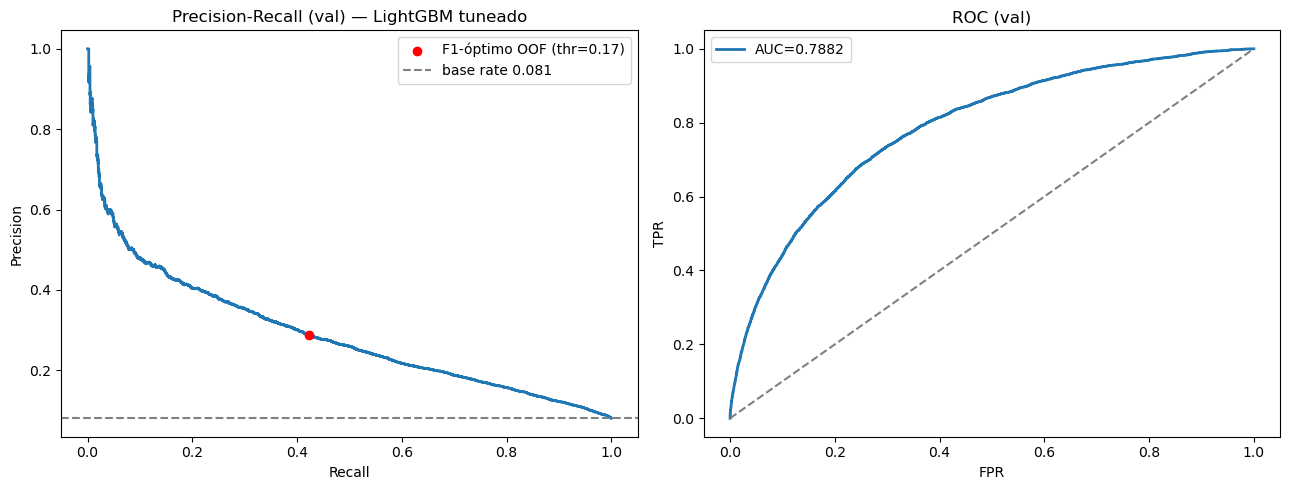

In [10]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

# 1. Umbral elegido FUERA de X_val: predicciones OOF de train con los params finales
print("Calculando predicciones OOF para tuning de umbral honesto...")
oof = np.zeros(len(X_tr_l))
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for itr, iva in skf.split(X_tr_l, y_tr):
    # Entrenamos con el fold de train usando los hiperparámetros ganadores
    b = lgb.train(
        best_p,
        lgb.Dataset(X_tr_l.iloc[itr], label=y_tr.iloc[itr], free_raw_data=False),
        num_boost_round=best_round
    )
    # Predecimos sobre el fold de validación (out-of-fold)
    oof[iva] = b.predict(X_tr_l.iloc[iva])

# 2. Encontramos el umbral F1-óptimo usando SOLO la data OOF de entrenamiento
prec_o, rec_o, thr_o = precision_recall_curve(y_tr, oof)
f1_o = 2 * prec_o[:-1] * rec_o[:-1] / (prec_o[:-1] + rec_o[:-1] + 1e-12)
i_f1 = int(np.argmax(f1_o))
thr_f1 = float(thr_o[i_f1])

print(f"Umbral F1-óptimo (OOF train) = {thr_f1:.3f}")

# 3. Recién ahora evaluamos el punto de operación sobre X_val INTACTO
prec, rec, thr = precision_recall_curve(y_val, p_val_f)

print("\n=== Puntos de operación sobre X_val (Holdout) ===")
for tr_rec in [0.50, 0.70, 0.80]:
    idx = np.where(rec[:-1] >= tr_rec)[0]
    j = idx[-1] if len(idx) else 0
    f1_val_j = 2 * prec[j] * rec[j] / (prec[j] + rec[j] + 1e-12)
    print(f"recall >= {tr_rec:.2f}: umbral= {thr[j]:.3f} | precision={prec[j]:.3f} recall={rec[j]:.3f} F1={f1_val_j:.3f}")

# Aplicamos el umbral OOF a las probabilidades del X_val
pred = (p_val_f >= thr_f1).astype(int)

print(f"\nConfusion matrix (val, umbral F1-óptimo OOF {thr_f1:.3f}):\n", confusion_matrix(y_val, pred))
print(f"De {len(y_val)} solicitudes marca {pred.sum()} como riesgosas ({(pred.mean()*100):.1f}%)")

# 4. Gráficos (manteniendo la visualización del desempeño sobre X_val)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(rec, prec, lw=2)

# Interpolamos para poner el puntito rojo del umbral OOF en la curva de validación
idx_val_opt = np.argmin(np.abs(thr - thr_f1))
ax[0].scatter(rec[idx_val_opt], prec[idx_val_opt], color='red', zorder=5, label=f'F1-óptimo OOF (thr={thr_f1:.2f})')
ax[0].axhline(y_val.mean(), ls='--', color='gray', label=f'base rate {y_val.mean():.3f}')
ax[0].set_xlabel('Recall'); ax[0].set_ylabel('Precision')
ax[0].set_title('Precision-Recall (val) — LightGBM tuneado'); ax[0].legend()

fpr, tpr, _ = roc_curve(y_val, p_val_f)
ax[1].plot(fpr, tpr, lw=2, label=f'AUC={auc(fpr, tpr):.4f}')
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set_xlabel('FPR'); ax[1].set_ylabel('TPR'); ax[1].set_title('ROC (val)')
ax[1].legend()

plt.tight_layout()
plt.savefig('reports/pr_roc_lgbm_tuned.png', dpi=110, bbox_inches='tight')
plt.show()

C:\Users\Usuario\anaconda3\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


Top 20 features por |SHAP| medio:
EXT_SOURCE_2                      0.2982
EXT_SOURCE_3                      0.2552
EXT_SOURCE_1                      0.1441
AMT_GOODS_PRICE                   0.1175
AMT_ANNUITY                       0.1161
CODE_GENDER                       0.1129
AMT_CREDIT                        0.1097
ORGANIZATION_TYPE                 0.0959
INST_INST_IS_LATE_MEAN            0.0947
INST_AMT_PAYMENT_SUM              0.0924
DAYS_EMPLOYED                     0.0843
POS_CNT_INSTALMENT_FUTURE_MEAN    0.0776
PREV_PREV_AMT_RATIO_MEAN          0.0775
DAYS_BIRTH                        0.0773
OWN_CAR_AGE                       0.0706
BUR_AMT_CREDIT_SUM_DEBT_MEAN      0.0705
NAME_FAMILY_STATUS                0.0690
NAME_EDUCATION_TYPE               0.0647
BUR_DAYS_CREDIT_ENDDATE_MAX       0.0527
BUR_AMT_CREDIT_MAX_OVERDUE_MAX    0.0520

CODE_GENDER: ranking #6 de 251 (|SHAP| medio = 0.1129) -> cuánto se apoya el modelo en el atributo protegido directo


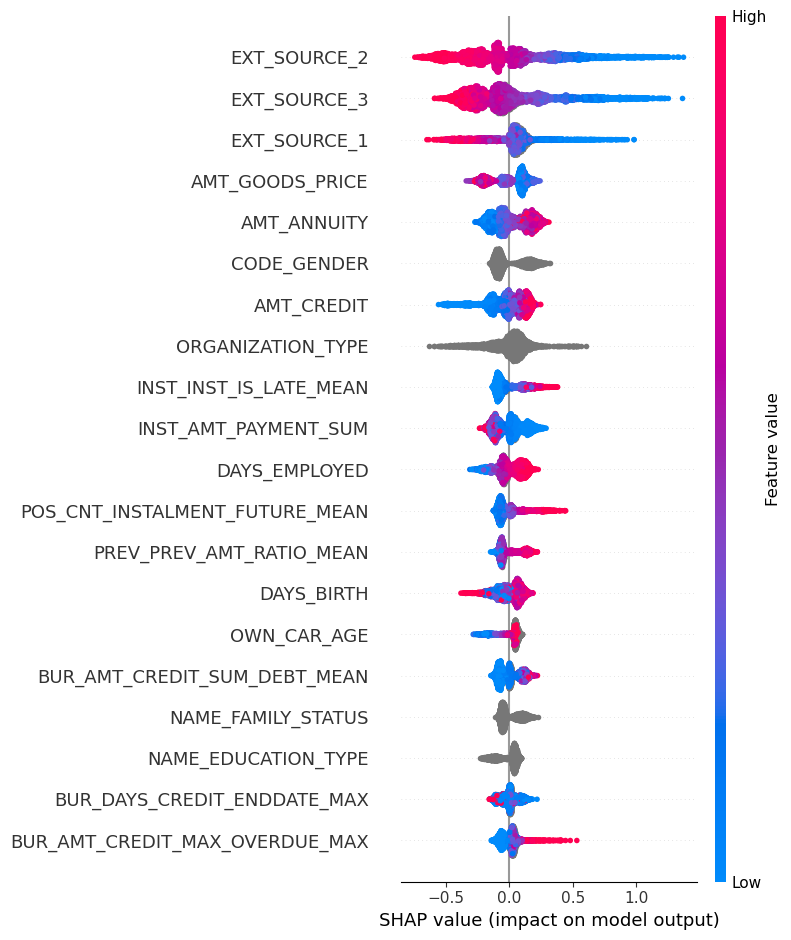

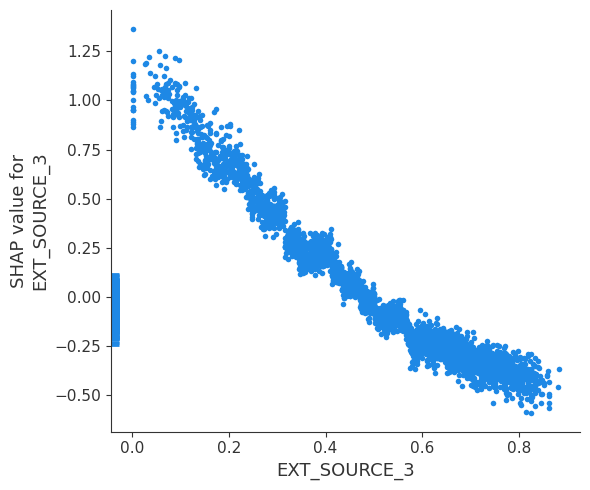

In [11]:
import shap

def to_codes(df):
    # formato que vio el modelo: categóricas -> códigos
    d = df.copy()
    for c in cat_cols:
        d[c] = d[c].cat.codes
    return d

Xs = X_val_l.sample(n=5000, random_state=42)

explainer = shap.TreeExplainer(final_booster)
sv = explainer.shap_values(Xs)

if isinstance(sv, list):
    sv = sv[1] # algunas versiones devuelven [clase0, clase1]

mean_abs = pd.Series(np.abs(sv).mean(0), index=Xs.columns).sort_values(ascending=False)
print("Top 20 features por |SHAP| medio:")
print(mean_abs.head(20).round(4).to_string())

rank_gender = list(mean_abs.index).index('CODE_GENDER') + 1
print(f"\nCODE_GENDER: ranking #{rank_gender} de {len(mean_abs)} "
      f"(|SHAP| medio = {mean_abs['CODE_GENDER']:.4f}) "
      f"-> cuánto se apoya el modelo en el atributo protegido directo")

shap.summary_plot(sv, Xs, max_display=20, show=False)
plt.tight_layout()
plt.savefig('reports/shap_summary.png', dpi=110, bbox_inches='tight')
plt.show()

shap.dependence_plot('EXT_SOURCE_3', sv, Xs, interaction_index=None, show=False)
plt.tight_layout()
plt.savefig('reports/shap_dep_ext3.png', dpi=110, bbox_inches='tight')
plt.show()

In [12]:
fair = pd.DataFrame({
    'gender': X_val['CODE_GENDER'].values,
    'age':   -X_val['DAYS_BIRTH'].values / 365.25,
    'y':      y_val.values,
    'p':      p_val_f})
THR = thr_f1

def group_metrics(sub):
    yt = sub['y'].values; pp = sub['p'].values
    pred = (pp >= THR).astype(int)
    tp = int(((pred==1)&(yt==1)).sum()); fp = int(((pred==1)&(yt==0)).sum())
    fn = int(((pred==0)&(yt==1)).sum()); tn = int(((pred==0)&(yt==0)).sum())
    return pd.Series({
        'n': len(sub),
        'default_real':   yt.mean(),
        'pred_prob_mean': pp.mean(),     # vs default_real -> calibración del grupo
        'AUC':       roc_auc_score(yt, pp),
        'flag_rate': pred.mean(),        # demographic parity / selection rate
        'recall':    tp/(tp+fn) if tp+fn else np.nan,   # equal opportunity (TPR)
        'FPR':       fp/(fp+tn) if fp+tn else np.nan,
        'precision': tp/(tp+fp) if tp+fp else np.nan,   # predictive parity
    })

gt = pd.DataFrame({g: group_metrics(fair[fair.gender == g]) for g in ['F', 'M']}).T
print(f"=== FAIRNESS por GÉNERO (umbral {THR:.3f}) ===")
print(gt.round(4).to_string())

labels = ['<25', '25-30', '30-40', '40-50', '50-60', '60+']
fair['age_grp'] = pd.cut(fair['age'], [0,25,30,40,50,60,200], labels=labels)
at = pd.DataFrame({lab: group_metrics(fair[fair.age_grp == lab]) for lab in labels}).T
print(f"\n=== FAIRNESS por EDAD (umbral {THR:.3f}) ===")
print(at.round(4).to_string())

=== FAIRNESS por GÉNERO (umbral 0.172) ===
         n  default_real  pred_prob_mean     AUC  flag_rate  recall     FPR  precision
F  40561.0        0.0699          0.0699  0.7830      0.093  0.3695  0.0722     0.2779
M  20940.0        0.1017          0.0999  0.7854      0.168  0.4955  0.1309     0.3000

=== FAIRNESS por EDAD (umbral 0.172) ===
             n  default_real  pred_prob_mean     AUC  flag_rate  recall     FPR  precision
<25     2392.0        0.1171          0.1230  0.7470     0.2337  0.5250  0.1951     0.2630
25-30   6513.0        0.1115          0.1103  0.7722     0.2027  0.5303  0.1616     0.2917
30-40  16491.0        0.0957          0.0948  0.7903     0.1554  0.4810  0.1210     0.2961
40-50  15299.0        0.0758          0.0762  0.7936     0.1075  0.4095  0.0827     0.2889
50-60  13620.0        0.0634          0.0614  0.7763     0.0682  0.3079  0.0520     0.2863
60+     7188.0        0.0497          0.0488  0.7446     0.0380  0.1989  0.0296     0.2601


In [13]:
print("=== Mitigación de Sesgo: Equal Opportunity (Igualdad de TPR) ===")

# 1. Elegimos el umbral por grupo sobre el vector OOF de Train (para no contaminar X_val)
TARGET_TPR = 0.45
gen_tr = X_tr_l['CODE_GENDER'].values
thr_g = {}

for g in ['F', 'M']:
    mg = gen_tr == g
    p_g, r_g, t_g = precision_recall_curve(y_tr.values[mg], oof[mg])
    ok = np.where(r_g[:-1] >= TARGET_TPR)[0]
    thr_g[g] = float(t_g[ok[-1]]) if len(ok) else 0.5

print(f"Umbrales ajustados en train OOF para apuntar a un TPR ~{TARGET_TPR}:")
print(f"Mujeres (F): {thr_g['F']:.3f} | Hombres (M): {thr_g['M']:.3f}")

# 2. Aplicamos los umbrales diferenciados sobre X_val INTACTO
gen_val = X_val_l['CODE_GENDER'].values
pred_eo = np.where(gen_val == 'M', p_val_f >= thr_g['M'], p_val_f >= thr_g['F']).astype(int)

# 3. Calculamos el impacto en el desempeño global
tp_eo = ((pred_eo == 1) & (y_val.values == 1)).sum()
fp_eo = ((pred_eo == 1) & (y_val.values == 0)).sum()
fn_eo = ((pred_eo == 0) & (y_val.values == 1)).sum()

prec_eo = tp_eo / (tp_eo + fp_eo) if (tp_eo + fp_eo) > 0 else 0
rec_eo = tp_eo / (tp_eo + fn_eo) if (tp_eo + fn_eo) > 0 else 0

print(f"\nDesempeño global tras mitigación:")
print(f"Precision = {prec_eo:.3f} | Recall = {rec_eo:.3f}")
print("\nNota para el informe: 'Mitigar el sesgo igualando la oportunidad (TPR) entre géneros "
      "requiere umbrales distintos y tiene un costo directo en la precisión global del modelo. "
      "Esto ilustra el tradeoff fundamental entre eficiencia algorítmica y equidad; "
      "una decisión que corresponde a política de negocio, no solo al área técnica.'")

=== Mitigación de Sesgo: Equal Opportunity (Igualdad de TPR) ===
Umbrales ajustados en train OOF para apuntar a un TPR ~0.45:
Mujeres (F): 0.139 | Hombres (M): 0.184

Desempeño global tras mitigación:
Precision = 0.270 | Recall = 0.458

Nota para el informe: 'Mitigar el sesgo igualando la oportunidad (TPR) entre géneros requiere umbrales distintos y tiene un costo directo en la precisión global del modelo. Esto ilustra el tradeoff fundamental entre eficiencia algorítmica y equidad; una decisión que corresponde a política de negocio, no solo al área técnica.'


In [14]:
gender_val = X_val['CODE_GENDER'].values

X_tr_ng  = X_tr_l.drop(columns=['CODE_GENDER'])
X_val_ng = X_val_l.drop(columns=['CODE_GENDER'])

d_ng = lgb.Dataset(X_tr_ng, label=y_tr, free_raw_data=False)
booster_ng = lgb.train(best_p, d_ng, num_boost_round=best_round)
p_val_ng = booster_ng.predict(X_val_ng)

auc_ng = roc_auc_score(y_val, p_val_ng)
print(f"AUC val SIN género: {auc_ng:.4f}  (CON género: {tun_val:.4f} | "
      f"costo: {tun_val-auc_ng:+.4f})")

print("\nProb. media predicha por género:")
for g in ['F', 'M']:
    m = gender_val == g
    print(f"  {g}: CON={p_val_f[m].mean():.4f} | SIN={p_val_ng[m].mean():.4f} "
          f"| real={y_val.values[m].mean():.4f}")

gap_con  = p_val_f[gender_val=='M'].mean()  - p_val_f[gender_val=='F'].mean()
gap_sin  = p_val_ng[gender_val=='M'].mean() - p_val_ng[gender_val=='F'].mean()
gap_real = y_val.values[gender_val=='M'].mean() - y_val.values[gender_val=='F'].mean()
print(f"\nGap M−F en prob predicha: CON={gap_con:.4f} | SIN={gap_sin:.4f} | real={gap_real:.4f}")

AUC val SIN género: 0.7864  (CON género: 0.7882 | costo: +0.0018)

Prob. media predicha por género:
  F: CON=0.0699 | SIN=0.0733 | real=0.0699
  M: CON=0.0999 | SIN=0.0937 | real=0.1017

Gap M−F en prob predicha: CON=0.0300 | SIN=0.0204 | real=0.0318


In [15]:
master_test = pd.read_parquet(PROC / 'master_test.parquet')
test_ids = master_test['SK_ID_CURR'].copy()

# Mismas columnas, orden y categorías que vio el modelo final
X_test = master_test[X_tr_l.columns.tolist()].copy()
for c in cat_cols:
    X_test[c] = pd.Categorical(X_test[c], categories=X_tr_l[c].cat.categories)

test_pred  = final_booster.predict(X_test)
submission = pd.DataFrame({'SK_ID_CURR': test_ids, 'TARGET': test_pred})
submission.to_csv('reports/submission_lgbm_tuned.csv', index=False)

print(submission.head())
print("shape:", submission.shape,
      "| prob media test:", round(test_pred.mean(), 4), "(base rate train 0.0807)")

   SK_ID_CURR    TARGET
0      100001  0.036179
1      100005  0.189034
2      100013  0.046211
3      100028  0.044012
4      100038  0.122473
shape: (48744, 2) | prob media test: 0.0716 (base rate train 0.0807)
